# 12｜深層神經網路訓練_梯度與遷移

用梯度範數與深度尺度理解消失、爆炸與裁剪。

對應 `slides/12_深層神經網路訓練_梯度與遷移.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/11_training_deep_neural_networks.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Glorot／He 初始化、Gradient Clipping、Transfer Learning。

- `MachineLearning2025/06_ANN_from_Scratch_MNIST.py`，固定 commit `3da2cb56b9efd17d7cd34602589f392554b40603`。
- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
depth = np.array([1, 2, 5, 10, 20])
sigmoid_upper = 0.25 ** depth
scale_table = pd.DataFrame({'depth': depth, 'sigmoid_derivative_upper_bound': sigmoid_upper})

gradient = np.array([3.0, 4.0, 12.0])
before = np.linalg.norm(gradient)
clip_norm = 5.0
clipped = gradient * min(1.0, clip_norm / before)
after = np.linalg.norm(clipped)
print(f'gradient norm: {before:.1f} -> {after:.1f}')
scale_table

gradient norm: 13.0 -> 5.0


,depth,sigmoid_derivative_upper_bound
0,1,2.500000e-01
1,2,6.250000e-02
2,5,9.765625e-04
3,10,9.536743e-07
4,20,9.094947e-13


## 執行結果圖

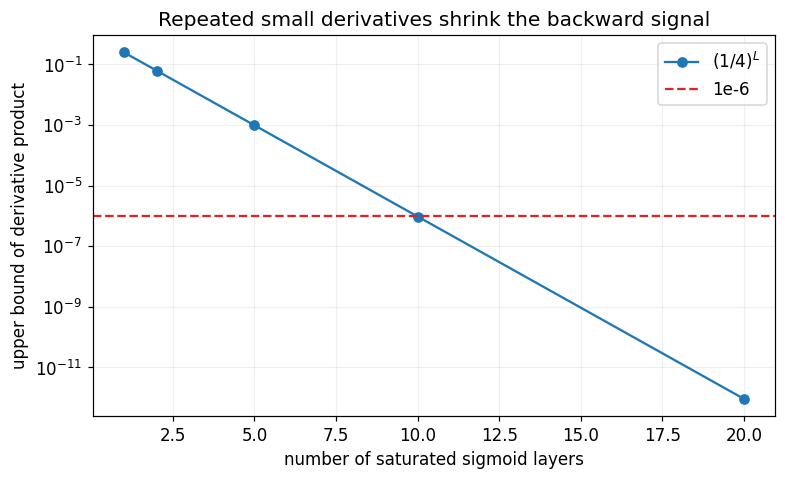

In [3]:
plt.semilogy(depth, sigmoid_upper, 'o-', label=r'$(1/4)^L$')
plt.axhline(1e-6, color='tab:red', ls='--', label='1e-6')
plt.xlabel('number of saturated sigmoid layers')
plt.ylabel('upper bound of derivative product')
plt.title('Repeated small derivatives shrink the backward signal')
plt.legend()
savefig('12_gradient_transfer_demo')
report('deep_gradient_transfer', {'gradient_norm_before': before, 'gradient_norm_after': after,
                                  'depths': depth.tolist(), 'sigmoid_upper': sigmoid_upper.tolist()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。